In [11]:
import pandas as pd
import numpy as np

# Load raw data
df = pd.read_csv("../rust/all_mse_log.csv")
df.head()

,composite_id,mse
0,1001,0.013136
1,1002,0.024824
2,1003,0.010694
3,1004,0.013908
4,1005,0.018855


In [12]:
df["unit_number"] = df["composite_id"] // 1000
df["time_in_cycles"] = df["composite_id"] % 1000

In [13]:
df.head()

,composite_id,mse,unit_number,time_in_cycles
0,1001,0.013136,1,1
1,1002,0.024824,1,2
2,1003,0.010694,1,3
3,1004,0.013908,1,4
4,1005,0.018855,1,5


In [17]:
# Calculate cycle_pct (how far into the engine's life is this cycle?)
# First, find the max cycle for each unit
max_cycles = df.groupby('unit_number')['time_in_cycles'].transform('max')
df['cycle_pct'] = df['time_in_cycles'] / max_cycles

# ==========================================
# SIMULATE SCENARIO A: Static Threshold
# ==========================================
# If MSE > 0.04 everywhere
df['flagged_static'] = df['mse'] > 0.04

# ==========================================
# SIMULATE SCENARIO B: Variable Threshold
# ==========================================

dynamic_threshold = np.where(df['time_in_cycles'] < 20, 0.05, 0.04)
df['flagged_variable'] = df['mse'] > dynamic_threshold

# ==========================================
# Analyze the Results
# ==========================================
print("--- TEST RESULTS ---")

early_life_df = df[df['cycle_pct'] <= 0.70]

# Count how many early false alarms happened under both scenarios
static_early_alarms = early_life_df['flagged_static'].sum()
variable_early_alarms = early_life_df['flagged_variable'].sum()

print(f"Early Alarms (Static 0.04):    {static_early_alarms}")
print(f"Early Alarms (Variable Fix):   {variable_early_alarms}")

# Calculate how many false alarms you successfully ignored!
saved_alarms = static_early_alarms - variable_early_alarms
if saved_alarms > 0:
    print(f"\nSUCCESS! successfully ignored {saved_alarms} break-in noise anomalies.")
else:
    print("\n something needs to be changed ")

--- TEST RESULTS ---
Early Alarms (Static 0.04):    179
Early Alarms (Variable Fix):   118

SUCCESS! successfully ignored 61 break-in noise anomalies.


In [15]:
df['flagged'] = df['flagged_variable']
late_count  = df[(df['cycle_pct'] > 0.70) & df['flagged']].shape[0]
early_count = df[(df['cycle_pct'] <= 0.70) & df['flagged']].shape[0]
print(f"late_cycle%: {late_count / (late_count + early_count):.1%}")

late_cycle%: 46.1%


count    118.000000
mean      41.042373
std       23.220752
min        1.000000
25%       25.250000
50%       37.000000
75%       54.750000
max      124.000000
Name: time_in_cycles, dtype: float64


<Axes: >

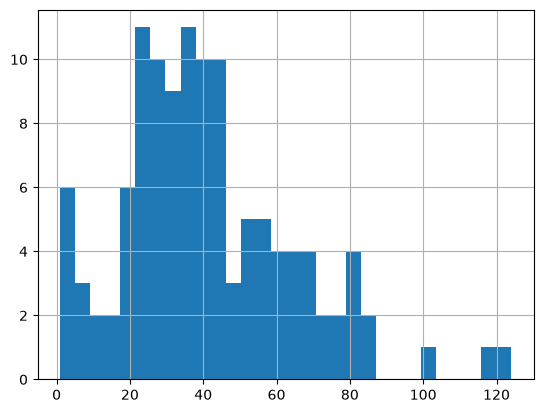

In [16]:
remaining_false = early_life_df[early_life_df['flagged_variable']]
print(remaining_false['time_in_cycles'].describe())
remaining_false['time_in_cycles'].hist(bins=30)
